<a href="https://colab.research.google.com/github/anjicx/Cormbobidity-Network-Analysis/blob/main/SNA_Analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [5]:
#install
!pip -q install statsmodels pyvis igraph

#imports
import math
from collections import Counter
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import networkx as nx

from pyvis.network import Network
from IPython.display import display, HTML
from statsmodels.stats.multitest import fdrcorrection


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 756.0/756.0 kB 13.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.7/5.7 MB 80.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 63.1 MB/s eta 0:00:00


In [6]:
# load data from git
if not Path("comorbidity_networks").exists():
    !git clone https://github.com/aaronab/comorbidity_networks.git
odds = pd.read_csv("comorbidity_networks/comorbidity_odds_matrix.csv", index_col=0)
pval = pd.read_csv("comorbidity_networks/comorbidity_pmat_matrix.csv", index_col=0)

In [7]:
# fdr correction
P = pval.copy()
n = P.shape[0]
mask = ~np.eye(n, dtype=bool)
pvals = P.values[mask]
_, qvals = fdrcorrection(pvals)

Q = np.zeros(P.shape, dtype=float)
Q[mask] = qvals
qmat = pd.DataFrame(Q, index=P.index, columns=P.columns)

# odds ratio and adjacency matrix
OR = np.exp(odds)
min_or = 1.5
alpha = 0.05

mask_edges = (qmat < alpha) & (OR > min_or)
A_or = OR.where(mask_edges, other=0)
A_adj = A_or.T

In [8]:
# build graph
G = nx.from_pandas_adjacency(A_adj, create_using=nx.DiGraph)
print("nodes:", G.number_of_nodes(), "edges:", G.number_of_edges())
for edge in list(G.edges(data=True))[:10]:
    print(edge)

nodes: 95 edges: 1327
('AHRQ_AbdominalHernia_DT', 'AHRQ_BiliaryTractDs_DT', {'weight': 1.7510259052116521})
('AHRQ_AbdominalHernia_DT', 'AHRQ_DisOfVeins_DT', {'weight': 1.5707891730630459})
('AHRQ_AbdominalHernia_DT', 'AHRQ_LowerGIDO_DT', {'weight': 1.7726702678282367})
('AHRQ_AbdominalHernia_DT', 'AHRQ_OthGIDO_DT', {'weight': 1.7065066422385244})
('AHRQ_AbdominalHernia_DT', 'AHRQ_UpperGIDO_DT', {'weight': 1.8640905036760718})
('AHRQ_AbdominalHernia_DT', 'cancerdxDT', {'weight': 1.5615514362698935})
('AHRQ_AcquiredDeformities_DT', 'AHRQ_InfectiveArthritis_DT', {'weight': 1.7400949708974736})
('AHRQ_AcquiredDeformities_DT', 'AHRQ_JointDisorderTraumarelated_', {'weight': 1.515271796604436})
('AHRQ_AcquiredDeformities_DT', 'AHRQ_Mycoses_DT', {'weight': 1.657085345643728})
('AHRQ_AcquiredDeformities_DT', 'AHRQ_NontraumaticJointDO_DT', {'weight': 1.5747635229776251})


In [9]:
# adjacency from graph
A_adj_from_graph = nx.to_pandas_adjacency(G)
A_adj_from_graph.iloc[:5, :5]

,AHRQ_AbdominalHernia_DT,AHRQ_AcquiredDeformities_DT,AHRQ_AdjustmentDO_DT,AHRQ_Anemia_DT,AHRQ_Asthma_DT
AHRQ_AbdominalHernia_DT,0.0,0.0,0.0,0.0,0.0
AHRQ_AcquiredDeformities_DT,0.0,0.0,0.0,0.0,0.0
AHRQ_AdjustmentDO_DT,0.0,0.0,0.0,0.0,0.0
AHRQ_Anemia_DT,0.0,0.0,0.0,0.0,0.0
AHRQ_Asthma_DT,0.0,0.0,0.0,0.0,0.0


In [10]:
# distance for shortest-path measures
eps = 1e-12
for u, v, d in G.edges(data=True):
    w = d.get("weight", 1.0)
    d["distance"] = 1.0 / (math.log1p(w) + eps)

In [11]:
# function for centralities
def centralities_for_graph(G0):
    out_strength = dict(G0.out_degree(weight="weight"))
    in_strength = dict(G0.in_degree(weight="weight"))
    in_deg = nx.in_degree_centrality(G0)
    out_deg = nx.out_degree_centrality(G0)
    in_close = nx.closeness_centrality(G0, distance="distance")
    out_close = nx.closeness_centrality(G0.reverse(), distance="distance")
    betw = nx.betweenness_centrality(G0, weight="distance", normalized=True)
    eig = nx.eigenvector_centrality(G0, weight="weight", max_iter=1000)
    return out_strength, in_strength, in_deg, out_deg, in_close, out_close, betw, eig

In [12]:
# dataframe from centralities
def centralities_df(G0, graph_name):
    out_strength, in_strength, in_deg, out_deg, in_close, out_close, betw, eig = centralities_for_graph(G0)

    df = pd.DataFrame({
        "out_strength": pd.Series(out_strength),
        "in_strength": pd.Series(in_strength),
        "in_deg": pd.Series(in_deg),
        "out_deg": pd.Series(out_deg),
        "in_close": pd.Series(in_close),
        "out_close": pd.Series(out_close),
        "betw": pd.Series(betw),
        "eig": pd.Series(eig),
    })
    df = df.reset_index().rename(columns={"index": "node"})
    return df

In [13]:
# mental and physical split
cols = A_adj.columns
nepec_re = r"^NEPEC_"
ahrq_mental_re = r"^AHRQ_(?:AdjustmentDO|AttentionDeficitDO|ImpulseControlDONEC|PersonalityDO|SuicideAndSelfInjury|DementiaAndOthDO|DevelopmentalDO|DOInChildhood)_DT$"

mental_mask = cols.str.contains(nepec_re, regex=True) | cols.str.contains(ahrq_mental_re, regex=True)
mental_cols = cols[mental_mask].tolist()
physical_cols = cols[~mental_mask].tolist()

mental_set = set(mental_cols)
mental_nodes = []
for n in G.nodes():
    if str(n) in mental_set:
        mental_nodes.append(n)

G_m = G.subgraph(mental_nodes).copy()
print("nodes mental:", G_m.number_of_nodes(), "edges:", G_m.number_of_edges())

nodes mental: 17 edges: 100


In [14]:
physical_set = set(physical_cols)
physical_nodes = []
for n in G.nodes():
    if str(n) in physical_set:
        physical_nodes.append(n)

G_p = G.subgraph(physical_nodes).copy()
print("nodes physical:", G_p.number_of_nodes(), "edges:", G_p.number_of_edges())

nodes physical: 78 edges: 928


In [16]:
# density
def densityFunction(G):
    return nx.density(G)

print("Density of the diseases graph: ", densityFunction(G))
print("Density of the physiological disease graph: ", densityFunction(G_p))
print("Density of the psychological disease graph: ", densityFunction(G_m))

# dataframes for graphs
df_full = centralities_df(G, "full")
df_m = centralities_df(G_m, "mental")
df_p = centralities_df(G_p, "physical")

# top k helper
def topk(df, metric, k=10):
    return (
        df.sort_values(metric, ascending=False)
          .loc[:, ["node", metric]]
          .head(k)
    )

print("How well-positioned a diagnosis is to be reached by others: ")
print(topk(df_full, "in_close"))
print(" ")
print("How well-positioned a diagnosis is to reach other diagnosis:")
print(topk(df_full, "out_close"))
print(" ")
print("How centrally a diagnosis lies on important paths between other diagnosis: ")
print(topk(df_full, "betw"))
print(" ")

Density of the diseases graph:  0.14860022396416572
Density of the physiological disease graph:  0.15451215451215453
Density of the psychological disease graph:  0.36764705882352944
How well-positioned a diagnosis is to be reached by others: 
                             node  in_close
39     AHRQ_InfectiveArthritis_DT  0.712756
12     AHRQ_ChronicUlcerOfSkin_DT  0.712342
73       AHRQ_SpinalCordInjury_DT  0.702940
30  AHRQ_FluidAndElectrolyteDO_DT  0.700406
70     AHRQ_RespiratoryFailure_DT  0.699218
68               AHRQ_Pleurisy_DT  0.698971
6      AHRQ_BacterialInfection_DT  0.697387
65              AHRQ_Paralysis_DT  0.690576
50           AHRQ_Osteoporosis_DT  0.684060
3                  AHRQ_Anemia_DT  0.680843
 
How well-positioned a diagnosis is to reach other diagnosis:
                                node  out_close
88                   NEPEC_DXODep_DT   1.056589
16          AHRQ_DementiaAndOthDO_DT   0.905926
65                 AHRQ_Paralysis_DT   0.777097
73          AHRQ_S

In [17]:
# strengths
out_strength = dict(G.out_degree(weight="weight"))
in_strength = dict(G.in_degree(weight="weight"))

def strength_for_graph(G0):
    out_strength = dict(G0.out_degree(weight="weight"))
    in_strength = dict(G0.in_degree(weight="weight"))
    return out_strength, in_strength

def strength_df(G0, graph_name):
    out_strength, in_strength = strength_for_graph(G0)
    df = pd.DataFrame({
        "out_strength": pd.Series(out_strength),
        "in_strength": pd.Series(in_strength),
    })
    df = df.reset_index().rename(columns={"index": "node"})
    return df

df_full_strength = strength_df(G, "full")
df_m_strength = strength_df(G_m, "mental")
df_p_strength = strength_df(G_p, "physical")


In [18]:
# cross-edge counts
def count_cross_edges_in_graph(G, mental_set, physical_set):
    m2p = 0
    p2m = 0
    m2m = 0
    p2p = 0
    other = 0

    for u, v in G.edges():
        u_is_m = str(u) in mental_set
        v_is_m = str(v) in mental_set
        u_is_p = str(u) in physical_set
        v_is_p = str(v) in physical_set

        if u_is_m and v_is_p:
            m2p += 1
        elif u_is_p and v_is_m:
            p2m += 1
        elif u_is_m and v_is_m:
            m2m += 1
        elif u_is_p and v_is_p:
            p2p += 1
        else:
            other += 1

    return {
        "mental→physical": m2p,
        "physical→mental": p2m,
        "mental→mental": m2m,
        "physical→physical": p2p,
        "other": other,
        "total_edges": G.number_of_edges()
    }

counts = count_cross_edges_in_graph(G, mental_set, physical_set)
print(counts)

{'mental→physical': 227, 'physical→mental': 72, 'mental→mental': 100, 'physical→physical': 928, 'other': 0, 'total_edges': 1327}


In [19]:
# top mental to physical outgoing edges
def top_cross_out_degree(G, mental_set, physical_set, topk=10):
    cnt = Counter()
    for u, v in G.edges():
        if str(u) in mental_set and str(v) in physical_set:
            cnt[u] += 1
    return cnt.most_common(topk)

print(top_cross_out_degree(G, mental_set, physical_set, topk=10))

[('NEPEC_DXODep_DT', 75), ('AHRQ_DementiaAndOthDO_DT', 48), ('NEPEC_SCHZ_DT', 29), ('NEPEC_DXDRG_DT', 26), ('NEPEC_PTSD_DT', 15), ('AHRQ_DevelopmentalDO_DT', 14), ('AHRQ_PersonalityDO_DT', 9), ('NEPEC_AFBPDX_DT', 5), ('AHRQ_SuicideAndSelfInjury_DT', 3), ('NEPEC_DXALC_DT', 2)]


In [20]:

# top strength tables
print("TOP 10 diagnoses with the strongest outgoing connections: ")
print(topk(df_full_strength, "out_strength"))
print(" ")
print("TOP 10 diagnoses with the strongest incoming connections: ")
print(topk(df_full_strength, "in_strength"))

print("TOP 10 diagnoses with the strongest outgoing connections (mental subgraph): ")
print(topk(df_m_strength, "out_strength"))
print("TOP 10 diagnoses with the strongest incoming connections (mental subgraph): ")
print(topk(df_m_strength, "in_strength"))

print("TOP 10 diagnoses with the strongest outgoing connections (physical disease subgraph): ")
print(topk(df_p_strength, "out_strength"))
print("TOP 10 diagnoses with the strongest incoming connections (physical disease subgraph): ")
print(topk(df_p_strength, "in_strength"))

TOP 10 diagnoses with the strongest outgoing connections: 
                                node  out_strength
65                 AHRQ_Paralysis_DT    548.655347
73          AHRQ_SpinalCordInjury_DT    307.076257
88                   NEPEC_DXODep_DT    183.482172
56             AHRQ_OthInfections_DT    182.622269
16          AHRQ_DementiaAndOthDO_DT    154.088381
15  AHRQ_CrushingInjuryOrInternalIn0     97.339376
12        AHRQ_ChronicUlcerOfSkin_DT     96.095755
39        AHRQ_InfectiveArthritis_DT     88.627183
83                    NEPEC_DXDRG_DT     77.556532
84                     NEPEC_SCHZ_DT     74.464221
 
TOP 10 diagnoses with the strongest incoming connections: 
                             node  in_strength
73       AHRQ_SpinalCordInjury_DT   500.097334
65              AHRQ_Paralysis_DT   239.488261
37             AHRQ_ImmunityDO_DT   172.938444
12     AHRQ_ChronicUlcerOfSkin_DT   161.962966
39     AHRQ_InfectiveArthritis_DT   104.410783
30  AHRQ_FluidAndElectrolyteDO_DT    

In [21]:
# node roles
def add_strength_role(df, in_col="in_strength", out_col="out_strength", q=0.75):
    df = df.copy()

    in_thr = df[in_col].quantile(q)
    out_thr = df[out_col].quantile(q)

    def strength_role(row):
        high_in = row[in_col] >= in_thr
        high_out = row[out_col] >= out_thr

        if high_in and high_out:
            return "hub"
        elif high_out and not high_in:
            return "predictor"
        elif high_in and not high_out:
            return "target"
        else:
            return "other"

    df["role"] = df.apply(strength_role, axis=1)
    return df

df_m_roles = add_strength_role(df_m_strength)
tmp = (df_m_roles[["node", "in_strength", "out_strength", "role"]]
    .sort_values("in_strength", ascending=False)
    .reset_index(drop=True)
    .head(20)
)
tmp.index = tmp.index + 1
print(tmp)


                            node  in_strength  out_strength       role
1   AHRQ_SuicideAndSelfInjury_DT    27.750829     15.735176     target
2          AHRQ_PersonalityDO_DT    27.434480     19.398785     target
3                  NEPEC_SCHZ_DT    26.552942     21.890029     target
4                NEPEC_AFBPDX_DT    22.668503     23.458959        hub
5        AHRQ_DevelopmentalDO_DT    21.719833     14.100193     target
6                 NEPEC_DXDRG_DT    21.659593     25.502704  predictor
7          AHRQ_DOInChildhood_DT    20.251327      7.953889      other
8    AHRQ_ImpulseControlDONEC_DT    19.692144      9.082261      other
9     AHRQ_AttentionDeficitDO_DT    13.747129      5.968341      other
10                NEPEC_DXALC_DT    13.604950      2.347411      other
11                  NEPEC_MDD_DT    12.021293      2.358051      other
12      AHRQ_DementiaAndOthDO_DT    10.558107     31.692761  predictor
13               NEPEC_DXODep_DT    10.134034     49.145493  predictor
14    

In [22]:
df_p_roles = add_strength_role(df_p_strength)
tmp = (
    df_p_roles[["node", "in_strength", "out_strength", "role"]]
    .sort_values("in_strength", ascending=False)
    .reset_index(drop=True)
    .head(20)
)
tmp.index = tmp.index + 1
# short labels
shortnamevec = [
    "Her","Def","Adj","Ane","Ast","ADHD","Bac","Bil","Bur","NIn","CVD","COPD","Ulc","Coag",
    "Coma","CIj","Dem","Dev","Art","Mou","Hea","Uri","Vei","WBC","Lip","Jaw","Ch","Ear",
    "Ep","Eye","Ele","Fr","GIH","Gou","HA","NSC","HTN","Imm","Imp","ArI","IIn","BIj","TJ",
    "Liv","LGI","Myc","NTJ","Gas","Nut","Wou","Ost","Bone","Con","End","GIO","HeO","InO",
    "SInf","IjO","LRO","NSO","NuO","SkO","URO","Pan","Par","PFr","Per","Ple","Poi","RF",
    "RIn","SIn","Spi","Bac","Spr","Sui","SuIj","Lup","Thy","UGI","Vir","Alc","Drg","Sch",
    "MDD","BPD","PTSD","DepO","AnxO","GAD","DM","Neo","Con","Gen"
]

cols = qmat.columns
assert len(cols) == len(shortnamevec), "Some column names are missing"
assert len(cols) == len(shortnamevec), "Short names have duplicates"

label_map = dict(zip(cols, shortnamevec))


nodes: 17 edges: 100


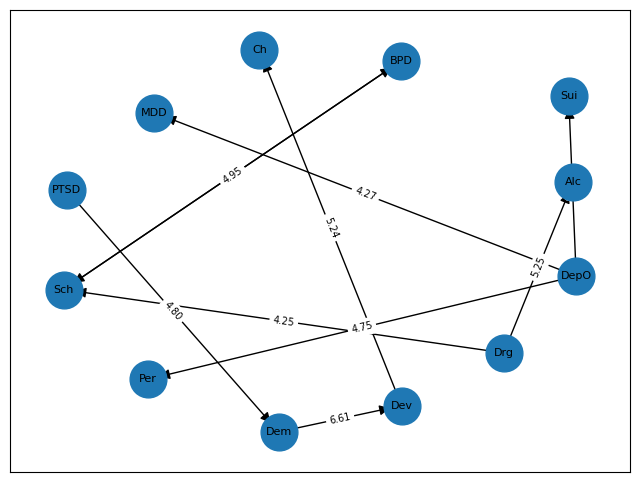

In [23]:
# mental subgraph for drawing
H = G.subgraph(mental_nodes).copy()
print("nodes:", H.number_of_nodes(), "edges:", H.number_of_edges())

def edge_weight(edge_tuple):
    return edge_tuple[2].get("weight")

def make_short_labels(G_sub, label_map):
    labels = {}
    for nodeId in G_sub.nodes():
        labels[nodeId] = label_map.get(nodeId, str(nodeId))
    return labels

# top 10 weighted edges in mental graph
edges_sorted = sorted(H.edges(data=True), key=edge_weight, reverse=True)
top_edges = edges_sorted[:10]

H2 = nx.DiGraph()
H2.add_edges_from(top_edges)
plt.figure(figsize=(8, 6))
pos = nx.spring_layout(H2, seed=1, k=6.0)

nx.draw_networkx_nodes(H2, pos, node_size=700)
nx.draw_networkx_edges(H2, pos, arrows=True, arrowstyle='-|>', arrowsize=15, width=1)

labels_short = make_short_labels(H2, label_map)
nx.draw_networkx_labels(H2, pos, labels=labels_short, font_size=8)

edge_labels = {(u, v): f"{d.get('weight', 0):.2f}" for u, v, d in H2.edges(data=True)}
nx.draw_networkx_edge_labels(H2, pos, edge_labels=edge_labels, font_size=7)

plt.show()

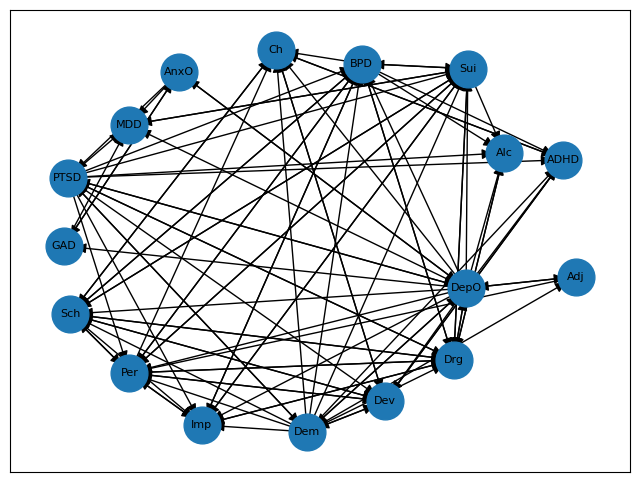

In [24]:
# top 100 weighted edges in mental graph
edges_sorted = sorted(H.edges(data=True), key=edge_weight, reverse=True)
top_edges = edges_sorted[:100]

H2 = nx.DiGraph()
H2.add_edges_from(top_edges)

plt.figure(figsize=(8, 6))
pos = nx.spring_layout(H2, seed=1, k=6.0)

nx.draw_networkx_nodes(H2, pos, node_size=700)
nx.draw_networkx_edges(H2, pos, arrows=True, arrowstyle='-|>', arrowsize=15, width=1)

labels_short = make_short_labels(H2, label_map)
nx.draw_networkx_labels(H2, pos, labels=labels_short, font_size=8)

plt.show()

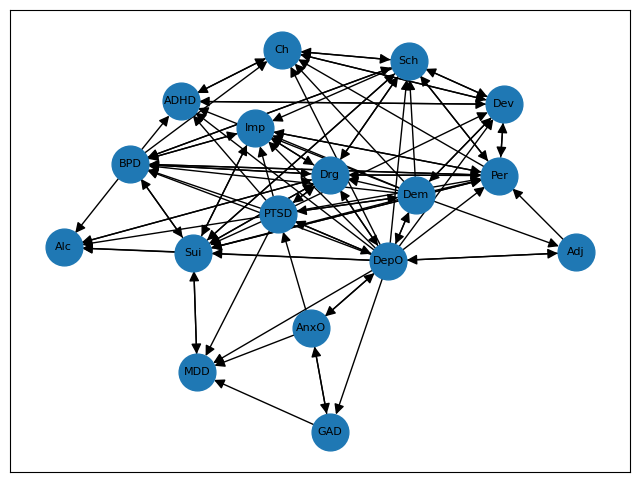

In [25]:
# kamada-kawai layout
plt.figure(figsize=(8, 6))
pos = nx.kamada_kawai_layout(H2)
scale = 3.0
pos = {n: (xy[0] * scale, xy[1] * scale) for n, xy in pos.items()}

nx.draw_networkx_nodes(H2, pos, node_size=700)
nx.draw_networkx_edges(
    H2, pos,
    arrows=True,
    arrowstyle='-|>',
    arrowsize=15,
    width=1,
    node_size=700,
    min_source_margin=2,
    min_target_margin=2
)

labels_short = make_short_labels(H2, label_map)
nx.draw_networkx_labels(H2, pos, labels=labels_short, font_size=8)

plt.show()

In [26]:
!pip -q install igraph leidenalg scikit-learn

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.7/2.7 MB 26.9 MB/s eta 0:00:00


In [27]:
#Transformacija u neusmereni graf da moze i za npr samo psihickih bolesti posmatranje kasnije
def to_undirected_projection_mean(G):
  #napravi neusmeren graf i doda cvorove usmerenog
    H = nx.Graph()#neusmeren graf
    H.add_nodes_from(G.nodes(data=True))#doda cvorove usmerenog
    loadedEdges=set()#SKUP UCITANIH IVICA
    for u,v in G.edges():
        a,b=sorted([u,v])#da uvek gleda jedan kao u drugi kao v i uv il vu je nebitno
        if (a,b) in loadedEdges:
            continue
        loadedEdges.add((a, b))
        w_uv = float(G[u][v].get("weight", 0.0)) if G.has_edge(u,v) else 0.0
        w_vu = float(G[v][u].get("weight", 0.0)) if G.has_edge(v,u) else 0.0
        w = (w_uv + w_vu) / 2.0
        if w > 0:
            H.add_edge(a, b, weight=w)
    return H

In [28]:
H_m= to_undirected_projection_mean(G_m)# mental undirected subgraph
H_p= to_undirected_projection_mean(G_p)# physical diseases undirected subgraph

In [29]:
from networkx.algorithms.community import louvain_communities
from networkx.algorithms.community.quality import modularity
from sklearn.metrics import normalized_mutual_info_score
import numpy as np
#POMOCNE FJE

def comms_to_map(comms):
    """
    list[set] -> dict node -> community_id
    """
    comm_map = {}
    for cid, nodeset in enumerate(comms):
        for n in nodeset:
            comm_map[n] = cid#dodeljulje dict cvor:klaster kojem pripada id
    return comm_map

def comm_map_to_labels(comm_map, nodes_order): ##JJ: nisam razumela sta ova f. radi i cemu sluzi
    """
    dict node->cid -> lista labela po fiksnom redosledu čvorova
    (treba za NMI)
    """
    return [comm_map[n] for n in nodes_order] #za dict cvor:klaster kojem pripada id
#NMI

In [30]:

#Louvain sa podesavanjem hiperparametara
def louvain_sweep(H, resolutions, seeds, weight="weight"):
    nodes_order = list(H.nodes())  #fiksan redosled čvorova(za NMI)
    rows = []
    labels_by_res = {res: [] for res in resolutions}
    comms_by_res_seed = {}

    for res in resolutions:
        for seed in seeds:
            comms = louvain_communities(H, weight=weight, resolution=res, seed=seed)
            comms_by_res_seed[(res, seed)] = comms

            comm_map = comms_to_map(comms)

            #labels u fiksnom redosledu čvorova
            labels = comm_map_to_labels(comm_map, nodes_order)
            labels_by_res[res].append(labels)

            #modularity za ovaj run
            Q = modularity(H, comms, weight=weight, resolution=res)

            rows.append({
                "resolution": res,
                "seed": seed,
                "n_communities": len(comms),
                "modularity": float(Q),
                "sizes": sorted([len(c) for c in comms], reverse=True)
            })

    df_runs = pd.DataFrame(rows)

    #rezime po resolution (stabilnost + kvalitet)
    summary_rows = []
    for res in resolutions:
        sub = df_runs[df_runs["resolution"] == res]
        k_mode = int(sub["n_communities"].mode().iloc[0])  # najčešći k
        k_mode_freq = int((sub["n_communities"] == k_mode).sum())

        summary_rows.append({
            "resolution": res,
            "runs": len(sub),
            "k_mode": k_mode,
            "k_mode_freq": k_mode_freq,
            "k_min": int(sub["n_communities"].min()),
            "k_max": int(sub["n_communities"].max()),
            "modularity_mean": float(sub["modularity"].mean()),
            "modularity_std": float(sub["modularity"].std(ddof=0)),
        })

    df_summary = pd.DataFrame(summary_rows).sort_values("resolution").reset_index(drop=True)
    return df_runs, df_summary, comms_by_res_seed

In [31]:
def representative_labels_by_resolution(df_runs, comms_by_res_seed, H, weight="weight"):
    """
    Za svaku rezoluciju uzima run sa max modularity i vraća:
    rep_labels[res] = labels lista po nodes_order

    JJ: Nisam razumela sta su "representative labels"
    """
    nodes_order = list(H.nodes())
    rep_labels = {}
    rep_choice = {}  # da vidiš koji seed je izabran

    for res in sorted(df_runs["resolution"].unique()):
        sub = df_runs[df_runs["resolution"] == res]
        best = sub.sort_values("modularity", ascending=False).iloc[0]
        best_seed = int(best["seed"])

        comms = comms_by_res_seed[(res, best_seed)]
        comm_map = comms_to_map(comms)
        labels = comm_map_to_labels(comm_map, nodes_order)

        rep_labels[res] = labels
        rep_choice[res] = {"seed": best_seed, "k": int(best["n_communities"]), "Q": float(best["modularity"])}

    return rep_labels, rep_choice

different resolutions

In [32]:
import numpy as np

resolutions = np.arange(0, 4.01, 0.1)  #od 0 do 4.0 sa rasponom 0.01
seeds = range(20)

df_runs, df_summary, comms_lookup = louvain_sweep(H_m, resolutions, seeds)
print(df_summary.head(18))

    resolution  runs  k_mode  k_mode_freq  k_min  k_max  modularity_mean  \
0          0.0    20       1           20      1      1         1.000000   
1          0.1    20       1           20      1      1         0.900000   
2          0.2    20       1           20      1      1         0.800000   
3          0.3    20       1           20      1      1         0.700000   
4          0.4    20       1           20      1      1         0.600000   
5          0.5    20       1           20      1      1         0.500000   
6          0.6    20       2           20      2      2         0.410661   
7          0.7    20       2           20      2      2         0.360662   
8          0.8    20       3           20      3      3         0.314287   
9          0.9    20       3           20      3      3         0.276218   
10         1.0    20       3           20      3      3         0.238149   
11         1.1    20       3           15      3      4         0.191799   
12         1

In [33]:
import numpy as np

def avg_nmi_vs_all(rep_labels):
    res_list = sorted(rep_labels.keys())
    rows = []

    for r1 in res_list:
        nmis = []
        for r2 in res_list:
            if r2 == r1:
                continue
            nmis.append(normalized_mutual_info_score(rep_labels[r1], rep_labels[r2]))

        rows.append({
            "resolution": r1,
            "avg_nmi_vs_all": float(np.mean(nmis)) if nmis else np.nan,
        })

    return pd.DataFrame(rows).sort_values("resolution").reset_index(drop=True)
rep_labels, rep_choice = representative_labels_by_resolution(df_runs, comms_lookup, H_m)
df_avg = avg_nmi_vs_all(rep_labels)
print(df_avg)

    resolution  avg_nmi_vs_all
0          0.0        0.125000
1          0.1        0.125000
2          0.2        0.125000
3          0.3        0.125000
4          0.4        0.125000
5          0.5        0.125000
6          0.6        0.469973
7          0.7        0.469973
8          0.8        0.615004
9          0.9        0.615004
10         1.0        0.615004
11         1.1        0.615004
12         1.2        0.615004
13         1.3        0.666112
14         1.4        0.666112
15         1.5        0.695937
16         1.6        0.695937
17         1.7        0.723185
18         1.8        0.723185
19         1.9        0.731031
20         2.0        0.725007
21         2.1        0.725007
22         2.2        0.725007
23         2.3        0.725007
24         2.4        0.725265
25         2.5        0.725265
26         2.6        0.733682
27         2.7        0.733682
28         2.8        0.733682
29         2.9        0.733682
30         3.0        0.728443
31      

In [34]:
import numpy as np

chosen_res = 0.8
sub = df_runs[np.isclose(df_runs["resolution"], chosen_res)].copy()

best_row = sub.sort_values("modularity", ascending=False).iloc[0]
best_seed = int(best_row["seed"])
chosen_res_used = float(best_row["resolution"])

comms = comms_lookup[(chosen_res_used, best_seed)]

In [35]:
for cid, c in enumerate(comms):
    print(f"Community {cid} (n={len(c)}):")
    print(sorted(c))
    print("-"*40)

Community 0 (n=7):
['AHRQ_ImpulseControlDONEC_DT', 'AHRQ_PersonalityDO_DT', 'AHRQ_SuicideAndSelfInjury_DT', 'NEPEC_AFBPDX_DT', 'NEPEC_DXALC_DT', 'NEPEC_DXDRG_DT', 'NEPEC_SCHZ_DT']
----------------------------------------
Community 1 (n=4):
['AHRQ_AttentionDeficitDO_DT', 'AHRQ_DOInChildhood_DT', 'AHRQ_DementiaAndOthDO_DT', 'AHRQ_DevelopmentalDO_DT']
----------------------------------------
Community 2 (n=6):
['AHRQ_AdjustmentDO_DT', 'NEPEC_ANXgen_DT', 'NEPEC_ANXunsp_DT', 'NEPEC_DXODep_DT', 'NEPEC_MDD_DT', 'NEPEC_PTSD_DT']
----------------------------------------


Edge thikness-weight of that edge
Node size-sum of all edges connected to that node/node strength

In [47]:
import matplotlib.pyplot as plt
import networkx as nx
import numpy as np

def plot_graph_communities(
    G,
    title,
    node_labels=None,
    node_color_modifiers=None,
    node_size_modifiers=None,
    edge_weight_multiplier=1.0,
    layout_seed=30,
    threshold_quantile=None
):
    # po želji filtriraj samo jače ivice
    if threshold_quantile is not None:
        weights = np.array([d["weight"] for _, _, d in G.edges(data=True)])
        threshold = np.quantile(weights, threshold_quantile)

        G_plot = nx.Graph()
        G_plot.add_edges_from(
            (u, v, d) for u, v, d in G.edges(data=True)
            if d["weight"] >= threshold
        )
    else:
        G_plot = G.copy()

    pos = nx.spring_layout(G, seed=layout_seed, k=0.35)

    nodes = list(G_plot.nodes())

    # boje po community
    if node_color_modifiers is None:
        node_colors = "lightblue"
    else:
        node_colors = [node_color_modifiers.get(n, -1) for n in nodes]

    # veličine čvorova
    if node_size_modifiers is None:
        node_sizes = 400
    else:
        vals = np.array([node_size_modifiers.get(n, 0) for n in nodes], dtype=float)
        vmin, vmax = vals.min(), vals.max()
        node_sizes = 300 + 1400 * (vals - vmin) / (vmax - vmin + 1e-9)

    # debljina ivica
    edges = list(G_plot.edges())
    if edges:
        ew = np.array([G_plot[u][v].get("weight", 1.0) for u, v in edges], dtype=float)
        ew_min, ew_max = ew.min(), ew.max()
        edge_widths = edge_weight_multiplier * (1 + 6 * (ew - ew_min) / (ew_max - ew_min + 1e-9))
    else:
        edge_widths = []

    # labele
    if node_labels is None:
        labels = {n: n for n in nodes}
    else:
        labels = {n: node_labels.get(n, n) for n in nodes}

    plt.figure(figsize=(12, 9))

    nx.draw_networkx_nodes(
        G_plot, pos,
        nodelist=nodes,
        node_color=node_colors,
        node_size=node_sizes,
        alpha=0.9
    )

    nx.draw_networkx_edges(
        G_plot, pos,
        edgelist=edges,
        width=edge_widths,
        alpha=0.5
    )

    nx.draw_networkx_labels(
        G_plot, pos,
        labels=labels,
        font_size=9
    )

    plt.title(title)
    plt.axis("off")
    plt.show()

In [48]:
def plot_louvain_graph(G, comms, title, label_map, edge_weight_multiplier=2.0, threshold_quantile=0.5):
    # node -> community id
    partition = {}
    for i, community in enumerate(comms):
        for node in community:
            partition[node] = i

    # short labels
    labels_dict = {node: label_map.get(node, node) for node in G.nodes()}

    # node size = weighted degree
    node_strength = dict(G.degree(weight="weight"))

    plot_graph_communities(
        G,
        title,
        node_labels=labels_dict,
        node_color_modifiers=partition,
        node_size_modifiers=node_strength,
        edge_weight_multiplier=edge_weight_multiplier,
        threshold_quantile=threshold_quantile
    )

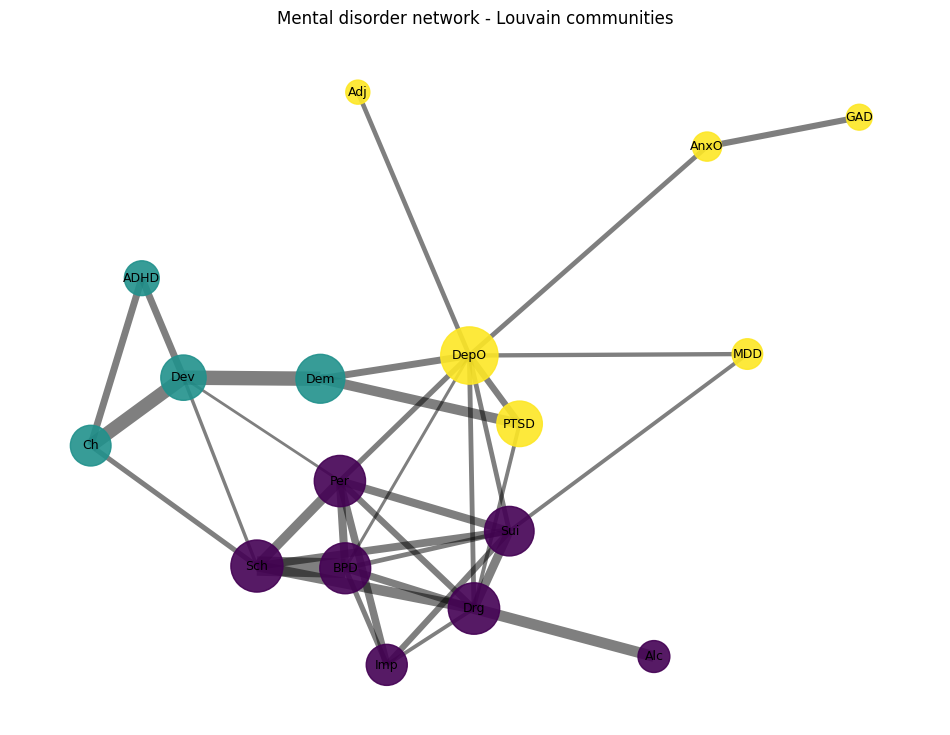

In [49]:
plot_louvain_graph(
    H_m,
    comms,
    "Mental disorder network - Louvain communities",
    label_map
)